## Проверка

In [14]:
import sys
import platform

import numpy as np
import pandas as pd

try:
    import sklearn
except Exception as e:
    sklearn = None
    print("⚠️ scikit-learn не импортируется:", e)

print("Python:", sys.version.split()[0])
print("Executable:", sys.executable)
print("OS:", platform.platform())

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
if sklearn is not None:
    print("scikit-learn:", sklearn.__version__)


Python: 3.12.3
Executable: /home/oflux/ml-course-homeworks/.venv/bin/python
OS: Linux-6.17.0-14-generic-x86_64-with-glibc2.39
NumPy: 2.4.2
Pandas: 3.0.1
scikit-learn: 1.8.0


## Pip

In [15]:
%pip install -U numpy pandas matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


## NumPy: создаём матрицу и считаем статистики

In [16]:
np.random.seed(666)

X = np.random.randn(66, 6)

print("X.shape:", X.shape)
print("X.dtype:", X.dtype)
print("First row:\n", X[:1])


X.shape: (66, 6)
X.dtype: float64
First row:
 [[ 0.82418808  0.479966    1.17346801  0.90904807 -0.57172145 -0.10949727]]


In [17]:
overall_mean = X.mean()
overall_std = X.std()

# TODO: статистики по столбцам
col_mean = X.mean(axis=0)
col_std = X.std(axis=0)
col_min = X.min(axis=0)
col_max = X.max(axis=0)

print("Overall mean:", overall_mean)
print("Overall std:", overall_std)
print("\nPer-column mean:", col_mean)
print("Per-column std:", col_std)
print("Per-column min:", col_min)
print("Per-column max:", col_max)

Overall mean: -0.00435990511494116
Overall std: 1.0111382512099498

Per-column mean: [ 0.02545378  0.09358297  0.04990009 -0.07978478 -0.08704438 -0.02826712]
Per-column std: [1.10103791 1.06379062 1.01225496 0.98957486 0.97528995 0.89935335]
Per-column min: [-3.19551031 -1.86097928 -2.76013122 -1.99209358 -1.94296661 -2.89257118]
Per-column max: [3.21727605 3.39351678 2.11748125 1.7392511  2.73504983 1.84611482]


## Векторизация

In [22]:
w = np.random.randn(6)
y = X @ w

print("w:", w)
print("y.shape:", y.shape)
print("y[:5]:", y[:6])


w: [-0.12355798 -0.85586573  0.31237396 -0.67863238  1.10170396 -1.22737392]
y.shape: (66,)
y[:5]: [-1.25844377  3.35267998  0.23624742 -1.85154988 -0.78040388  0.76391347]


In [24]:
w_true = np.array([1.5, -2.0, 0.0, 0.7, 3.0, 4.5])
noise = 0.1 * np.random.randn(X.shape[0])
y_true = X @ w_true + noise

# TODO: "предсказанные" веса и y_pred (можете взять w_true + небольшой шум)
w_guess = w_true + 0.5 * np.random.randn(6)
y_pred = X @ w_guess

# Метрики
mse = np.mean((y_true - y_pred) ** 2)
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(mse)

# TODO (bonus): R2
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MSE: 0.9490197072208109
MAE: 0.8078628713454785
RMSE: 0.9741764251001
R2: 0.966270288798123


## Pandas

In [26]:
col_names = [f"x{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=col_names)

# TODO: добавьте target
df["target"] = y_true

display(df.head())
print("Shape:", df.shape)
display(df.describe())
print("\nMissing values:\n", df.isnull().sum())

,x0,x1,x2,x3,x4,x5,target
0,0.824188,0.479966,1.173468,0.909048,-0.571721,-0.109497,-1.262974
1,0.019028,-0.943761,0.640573,-0.786443,0.608870,-0.931012,-1.037737
2,0.978222,-0.736918,-0.298733,-0.460587,-1.088793,-0.575771,-3.251393
3,-1.682901,0.229185,-1.756625,0.844633,0.277220,0.852902,2.241871
4,0.194600,1.310638,1.543844,-0.529048,-0.656472,-0.201506,-5.616696


Shape: (66, 7)


,x0,x1,x2,x3,x4,x5,target
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,0.025454,0.093583,0.049900,-0.079785,-0.087044,-0.028267,-0.606711
std,1.109475,1.071942,1.020012,0.997158,0.982764,0.906245,5.344986
min,-3.195510,-1.860979,-2.760131,-1.992094,-1.942967,-2.892571,-15.801351
25%,-0.629035,-0.654608,-0.657520,-0.885246,-0.707304,-0.566855,-4.015923
50%,0.062218,-0.052376,0.017042,-0.059709,-0.055991,-0.048537,-0.341192
75%,0.784927,0.684792,0.805403,0.626564,0.571559,0.522533,2.871280
max,3.217276,3.393517,2.117481,1.739251,2.735050,1.846115,9.541100



Missing values:
 x0        0
x1        0
x2        0
x3        0
x4        0
x5        0
target    0
dtype: int64


In [27]:
filtered = df[df["x0"] > 0].sort_values("target", ascending=False)
display(filtered.head(10))

,x0,x1,x2,x3,x4,x5,target
43,1.104360,0.524455,-1.061627,-0.385518,0.573323,1.505110,8.826507
29,1.767456,-0.787623,0.785902,-0.371990,1.011497,0.281764,8.141003
57,1.384425,0.124338,1.720315,-0.754856,1.106738,0.635161,7.438288
54,0.597976,-0.450606,0.043007,-1.055097,-0.057015,1.220976,6.377591
34,0.725001,-0.006846,-0.247840,-1.687946,-0.998205,1.846115,5.418291
61,0.201078,-1.860979,-1.159130,0.542854,0.202741,0.004387,5.094191
26,0.613559,-0.182291,0.314158,0.878672,-0.427067,0.920380,4.834234
21,0.274608,-1.530129,1.152587,-0.903398,0.185628,0.205235,4.415043
13,0.800130,0.677755,-0.950429,-0.057077,0.359511,0.522946,3.196982
23,3.217276,-1.114928,-0.658397,0.373584,-1.128170,-0.148481,3.191611


In [28]:
df["x0_bin"] = pd.cut(df["x0"], bins=4)

grouped = df.groupby("x0_bin")["target"].mean()
display(grouped)


x0_bin
(-3.202, -1.592]   -6.080838
(-1.592, 0.0109]   -0.526815
(0.0109, 1.614]    -0.220428
(1.614, 3.217]      5.666307
Name: target, dtype: float64

Визуализация

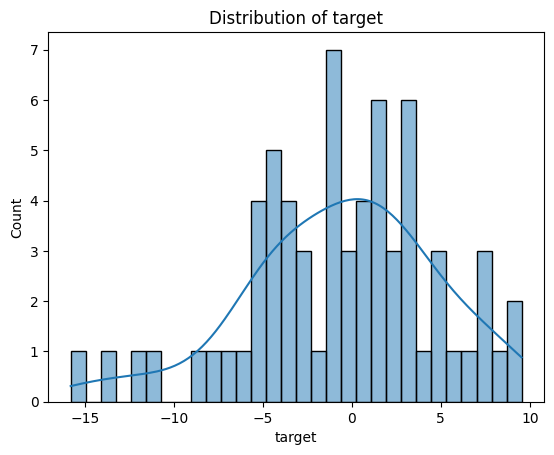

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: гистограмма
plt.figure()
sns.histplot(df["target"], bins=30, kde=True)
plt.title("Distribution of target")
plt.show()


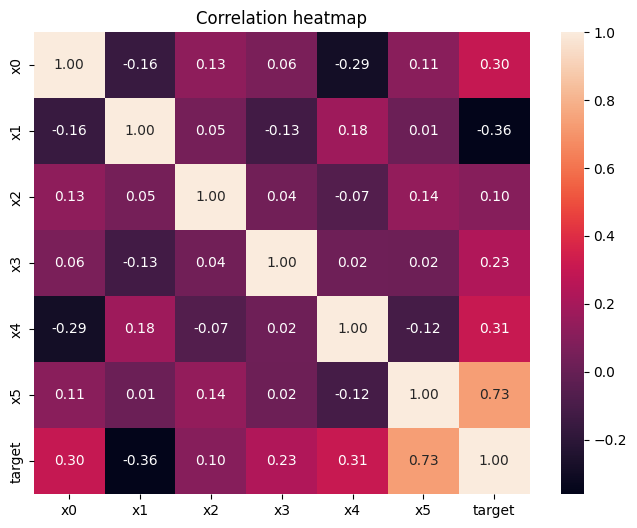

In [30]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.show()


## Iris Dataset


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


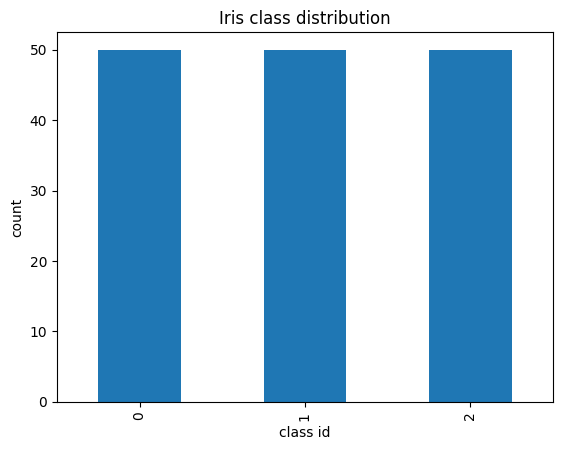

Accuracy: 0.9666666666666667

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [31]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
display(iris_df.head())

print("Class distribution:")
print(iris_df["target"].value_counts())

plt.figure()
iris_df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Iris class distribution")
plt.xlabel("class id")
plt.ylabel("count")
plt.show()

# Train/test split
X_iris = iris_df.drop(columns=["target"])
y_iris = iris_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
